# Feature A: Similar Product Recommendation
## Preprocessing, EDA & Baseline Model

### Objective
Build a deterministic content-based recommendation system that takes a product or search term and returns similar products ranked by relevance.

### Approach
This notebook will:
1. Load and validate the cleaned product dataset
2. Analyze relevant product attributes
3. Prepare text features
4. Build a TF-IDF + Cosine Similarity baseline
5. Generate recommendations
6. Evaluate recommendation quality
7. Compare candidate approaches in the next stage

In [2]:
#Cell 2 — Imports
import os
import re
import json
import numpy as np
import pandas as pd

from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt

pd.set_option("display.max_colwidth", 150)
pd.set_option("display.max_columns", None)

RANDOM_STATE = 42

In [ ]:
"""from google.colab import files
uploaded = files.upload()"""

Saving cleaned_products.csv to cleaned_products.csv


In [2]:
from pathlib import Path
import pandas as pd

# Point to project root (2 folders up from this notebook)
PROJECT_ROOT = Path.cwd().parents[1]

# Path to the dataset
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "cleaned_products.csv"

# Load the dataset
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully! Shape:", df.shape)

Dataset loaded successfully! Shape: (946, 17)


In [19]:
"""import pandas as pd

# Load dataset from local session files
df = pd.read_csv("cleaned_products.csv")

print(f"Dataset shape: {df.shape}")
df.head(1)"""

'import pandas as pd\n\n# Load dataset from local session files\ndf = pd.read_csv("cleaned_products.csv")\n\nprint(f"Dataset shape: {df.shape}")\ndf.head(1)'

In [20]:
#Cell 5 — Dataset Schema Inspection
print("=" * 80)
print("DATASET INFO")
print("=" * 80)

print("\nColumns:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print("\nMissing values:")
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2)
})

display(
    missing[missing["missing_count"] > 0]
    .sort_values("missing_count", ascending=False)
)

DATASET INFO

Columns:
['product_number', 'asin', 'search_keyword', 'title', 'url', 'price', 'description', 'description_imputed', 'brand', 'image', 'review_count', 'average_rating', 'video_url', 'reviews', 'review_number_collected', 'title_length', 'description_length']

Data types:


,dtype
product_number,int64
asin,str
search_keyword,str
title,str
url,str
price,float64
description,str
description_imputed,bool
brand,str
image,str



Missing values:


,missing_count,missing_percent
video_url,12,1.27


In [21]:
#Cell 6 — Feature A Relevant Data Quality Check
recommendation_columns = [
    "asin",
    "search_keyword",
    "title",
    "description",
    "brand",
    "price",
    "review_count",
    "average_rating"
]

available_columns = [
    col for col in recommendation_columns
    if col in df.columns
]

print("Available recommendation-related columns:")
print(available_columns)

display(df[available_columns].head())

Available recommendation-related columns:
['asin', 'search_keyword', 'title', 'description', 'brand', 'price', 'review_count', 'average_rating']


,asin,search_keyword,title,description,brand,price,review_count,average_rating
0,B0HCNYJM8Z,wireless earbuds,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...","About this item\r\nSecure Fit for High-Intensity Sports & Specific Ergonomics: Engineered for continuous movement, these earbuds wireless bluetoot...",Csasan,25.99,9662,4.4
1,B0GFF3RCCL,wireless earbuds,"TALIX T30 Noise Cancelling Earbuds with Phone Stand, Punchy Bass, 4-Mic, True Wireless Bluetooth 6.0 in Ear Headphones, 28H Playtime, IPX4(Off-White)","About this item\r\n【Punchy Bass】 Featuring 10mm titanium-composite diaphragm drivers, TALIX T30 noise-cancelling earbuds deliver punchy bass and v...",TALIX,25.99,67,4.3
2,B0HBWW3958,wireless earbuds,"Wireless Earbuds, Bluetooth 5.3 Headphones HiFi Stereo 50H Playback LED Digital Display Ear Buds with ENC Noise Canceling Headset, IPX7 Waterproof...",About this item\r\nSmart LED Display & 50H Sport Headphones: The A10 Bluetooth 5.3 earbuds feature an LED screen that shows real-time power levels...,Brand: Fhumsh,19.98,196,5.0
3,B0H9LHWBDK,wireless earbuds,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphones Bass Stereo Ear Buds with Noise Cancelling Mic, LED Display in Ear Earphones 50H Playtime Ear Buds...",About this item\r\nLED Power Display and 50H Playback: Dual digital LED power display outside of the case is to show the power level for charging ...,Brand: XIAOWTEK,18.99,782,4.6
4,B0H7R1LD7B,wireless earbuds,"HAOYUYAN Wireless Earbuds, Sports Bluetooth Headphones, 80Hrs Playtime Ear Buds with LED Power Display, Noise Canceling Headset, IPX7 Waterproof E...","About this item\r\n【Sports Comfort & IPX7 Waterproof】BX17 Wireless Earbuds are crafted with elastic soft ear hooks, offering a snug and comfortabl...",HAOYUYAN,23.98,371,4.6


In [22]:
#Cell 7 — Check Duplicate Products
print("Total products:", len(df))

print("\nDuplicate ASINs:")
print(df["asin"].duplicated().sum())

print("\nDuplicate titles:")
print(df["title"].duplicated().sum())

print("\nUnique search keywords:")
print(df["search_keyword"].nunique())

Total products: 946

Duplicate ASINs:
0

Duplicate titles:
51

Unique search keywords:
28


In [23]:
#Cell 8 — Text Cleaning Function
def clean_text(text):
    """
    Basic text cleaning for product recommendation.
    Keeps product-related words while removing formatting noise.
    """

    if pd.isna(text):
        return ""

    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Replace non-alphanumeric characters with spaces
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [24]:
#Cell 9 — Create Clean Recommendation Dataset
feature_a_df = df.copy()

text_columns = [
    "search_keyword",
    "title",
    "description",
    "brand"
]

for col in text_columns:
    if col in feature_a_df.columns:
        feature_a_df[f"{col}_clean"] = (
            feature_a_df[col]
            .fillna("")
            .apply(clean_text)
        )

print("Feature A dataset shape:", feature_a_df.shape)

display(
    feature_a_df[
        [
            "asin",
            "title",
            "brand",
            "search_keyword"
        ]
    ].head()
)

Feature A dataset shape: (946, 21)


,asin,title,brand,search_keyword
0,B0HCNYJM8Z,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",Csasan,wireless earbuds
1,B0GFF3RCCL,"TALIX T30 Noise Cancelling Earbuds with Phone Stand, Punchy Bass, 4-Mic, True Wireless Bluetooth 6.0 in Ear Headphones, 28H Playtime, IPX4(Off-White)",TALIX,wireless earbuds
2,B0HBWW3958,"Wireless Earbuds, Bluetooth 5.3 Headphones HiFi Stereo 50H Playback LED Digital Display Ear Buds with ENC Noise Canceling Headset, IPX7 Waterproof...",Brand: Fhumsh,wireless earbuds
3,B0H9LHWBDK,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphones Bass Stereo Ear Buds with Noise Cancelling Mic, LED Display in Ear Earphones 50H Playtime Ear Buds...",Brand: XIAOWTEK,wireless earbuds
4,B0H7R1LD7B,"HAOYUYAN Wireless Earbuds, Sports Bluetooth Headphones, 80Hrs Playtime Ear Buds with LED Power Display, Noise Canceling Headset, IPX7 Waterproof E...",HAOYUYAN,wireless earbuds


In [25]:
#Cell 10 — Create Baseline Product Text
feature_a_df["baseline_text"] = (
    feature_a_df["title_clean"] + " " +
    feature_a_df["title_clean"] + " " +
    feature_a_df["description_clean"]
).str.strip()

print("Empty baseline texts:")
print((feature_a_df["baseline_text"] == "").sum())

display(
    feature_a_df[
        ["asin", "title", "baseline_text"]
    ].head(3)
)

Empty baseline texts:
0


,asin,title,baseline_text
0,B0HCNYJM8Z,"Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear,...",wireless sports earbuds with secure earhooks 48h deep bass enc mic ear bud wireless earphone with led display bluetooth 5 3 headphones in ear ipx7...
1,B0GFF3RCCL,"TALIX T30 Noise Cancelling Earbuds with Phone Stand, Punchy Bass, 4-Mic, True Wireless Bluetooth 6.0 in Ear Headphones, 28H Playtime, IPX4(Off-White)",talix t30 noise cancelling earbuds with phone stand punchy bass 4 mic true wireless bluetooth 6 0 in ear headphones 28h playtime ipx4 off white ta...
2,B0HBWW3958,"Wireless Earbuds, Bluetooth 5.3 Headphones HiFi Stereo 50H Playback LED Digital Display Ear Buds with ENC Noise Canceling Headset, IPX7 Waterproof...",wireless earbuds bluetooth 5 3 headphones hifi stereo 50h playback led digital display ear buds with enc noise canceling headset ipx7 waterproof e...


In [26]:
#Cell 11 — Text Length EDA
feature_a_df["baseline_text_length"] = (
    feature_a_df["baseline_text"]
    .str.split()
    .str.len()
)

print(
    feature_a_df["baseline_text_length"]
    .describe()
)

count    946.000000
mean     236.513742
std      129.549020
min        7.000000
25%      125.250000
50%      238.000000
75%      321.750000
max      681.000000
Name: baseline_text_length, dtype: float64


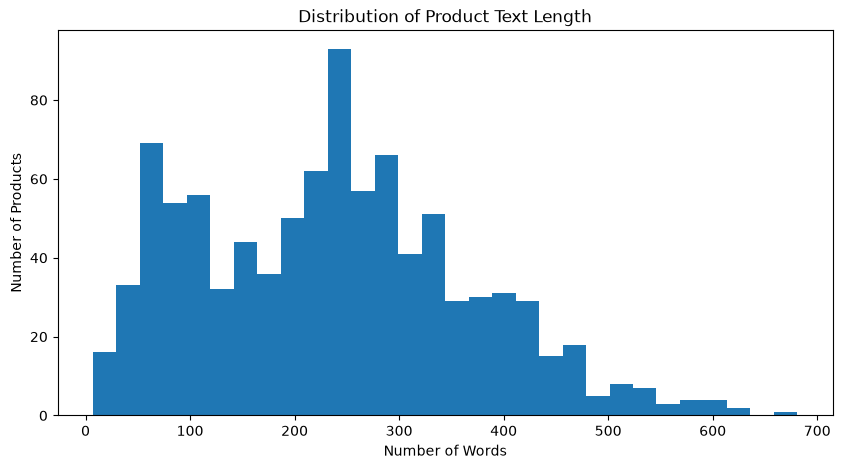

In [27]:
#Cell 12 — Visualize Text Length Distribution
plt.figure(figsize=(10, 5))

plt.hist(
    feature_a_df["baseline_text_length"],
    bins=30
)

plt.title("Distribution of Product Text Length")
plt.xlabel("Number of Words")
plt.ylabel("Number of Products")

plt.show()

In [28]:
#Cell 13 — TF-IDF Vectorization
tfidf_baseline = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

baseline_matrix = tfidf_baseline.fit_transform(
    feature_a_df["baseline_text"]
)

print("TF-IDF matrix shape:", baseline_matrix.shape)

TF-IDF matrix shape: (946, 24320)


In [29]:
#Cell 14 — Cosine Similarity Matrix
baseline_similarity_matrix = cosine_similarity(
    baseline_matrix,
    baseline_matrix
)

print(
    "Similarity matrix shape:",
    baseline_similarity_matrix.shape
)

Similarity matrix shape: (946, 946)


In [30]:
#Cell 15 — Recommendation Function
def recommend_by_product(
    product_asin,
    dataframe,
    similarity_matrix,
    top_k=5
):
    """
    Return top-K similar products for a given ASIN.

    Deterministic:
    - Primary sort: similarity descending
    - Secondary sort: ASIN ascending
    """

    matches = dataframe.index[
        dataframe["asin"] == product_asin
    ].tolist()

    if not matches:
        raise ValueError(
            f"Product ASIN '{product_asin}' not found."
        )

    product_idx = matches[0]

    similarity_scores = similarity_matrix[product_idx]

    recommendations = pd.DataFrame({
        "index": dataframe.index,
        "similarity_score": similarity_scores,
        "asin": dataframe["asin"].values
    })

    # Remove the query product itself
    recommendations = recommendations[
        recommendations["index"] != product_idx
    ]

    # Deterministic sorting
    recommendations = recommendations.sort_values(
        by=["similarity_score", "asin"],
        ascending=[False, True]
    )

    top_indices = (
        recommendations
        .head(top_k)["index"]
        .tolist()
    )

    result = dataframe.loc[
        top_indices,
        [
            "asin",
            "title",
            "brand",
            "search_keyword",
            "price"
        ]
    ].copy()

    result["similarity_score"] = (
        recommendations
        .head(top_k)["similarity_score"]
        .values
    )

    return result

In [31]:
#Cell 16 — Test the Baseline
sample_product = feature_a_df.iloc[100]

print("QUERY PRODUCT")
print("-" * 80)
print("ASIN:", sample_product["asin"])
print("Title:", sample_product["title"])
print("Brand:", sample_product["brand"])
print("Search Keyword:", sample_product["search_keyword"])

print("\nRECOMMENDATIONS")
display(
    recommend_by_product(
        product_asin=sample_product["asin"],
        dataframe=feature_a_df,
        similarity_matrix=baseline_similarity_matrix,
        top_k=5
    )
)

QUERY PRODUCT
--------------------------------------------------------------------------------
ASIN: B0HC3H4KVF
Title: Smart Watch for Women, 120 Sports Modes Smartwatch with 1.83" HD, Alexa Built-in, Heart Rate/Sleep Monitor, IP67 Waterproof, Bluetooth Call & Music Control Fitness Watch for iPhone/Android (Pink)
Brand: TRAUSI
Search Keyword: smartwatch

RECOMMENDATIONS


,asin,title,brand,search_keyword,price,similarity_score
88,B0HC376WZX,"Smart Watch for Men, 120 Sports Modes Smartwatch with 1.83"" HD, Alexa Built-in, Heart Rate/Sleep Monitor, IP67 Waterproof, Bluetooth Call & Music ...",TRAUSI,smartwatch,19.99,0.990409
98,B0HBQ5M712,"Smart Watch for Men Women with Alexa Built-in, Bluetooth Calling, 1.83'' HD Touch Screen Fitness Tracker with Heart Rate/Sleep Monitor, 120+ Sport...",BOOOMIC,smartwatch,23.99,0.298207
97,B0GS5BWJLF,"Smart Watches for Women,1.85"" HD Smartwatch Fitness Trackers, with 2 Bands | 100+ Sports Mode/1000mAh Battery/Compatible iPhone or Android/Heart R...",RUXINGX,smartwatch,49.99,0.266600
93,B0FWR4VJ87,"Smart Watch for Men Women (Answer/Make Call), 1.83"" HD Touchscreen Fitness Tracker, 110+ Sport Modes, Fitness Watch with Heart Rate/Sleep Monitor/...",Coucur,smartwatch,14.99,0.264901
106,B0H4T9F3CH,"Smart Watch for Women Men, Alexa Built-in, Smartwatch for iPhone & Android Bluetooth Call, 1.91"" HD Fitness Tracker with Heart Rate/SpO2/Sleep Mon...",Jugeman,smartwatch,32.99,0.262813


In [32]:
#Cell 17 — Test Multiple Products
sample_indices = [0, 100, 300]

for idx in sample_indices:

    product = feature_a_df.iloc[idx]

    print("\n" + "=" * 100)
    print("QUERY PRODUCT")
    print("=" * 100)

    print(
        f"ASIN: {product['asin']}"
    )

    print(
        f"Title: {product['title']}"
    )

    print(
        f"Keyword: {product['search_keyword']}"
    )

    recommendations = recommend_by_product(
        product_asin=product["asin"],
        dataframe=feature_a_df,
        similarity_matrix=baseline_similarity_matrix,
        top_k=5
    )

    display(recommendations)


QUERY PRODUCT
ASIN: B0HCNYJM8Z
Title: Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear, IPX7 Waterproof Over Ear Buds for Running/Workout
Keyword: wireless earbuds


,asin,title,brand,search_keyword,price,similarity_score
3,B0H9LHWBDK,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphones Bass Stereo Ear Buds with Noise Cancelling Mic, LED Display in Ear Earphones 50H Playtime Ear Buds...",Brand: XIAOWTEK,wireless earbuds,18.99,0.328194
8,B0HBW8PTYN,"Wireless Earbuds, Bluetooth 5.4 Headphones HIFI Stereo/Crystal clear, White | Noise Cancelling Mic Ear buds with 50H Playback, LED Digital Display...",Brand: Fhumsh,wireless earbuds,19.99,0.321690
19,B0H6VZSB53,Active Noise Cancelling Ear Buds Wireless Earbuds 90H Playtime Bluetooth Headphones Stereo Bass Over-Ear Hooks Earphones with Power Display Case I...,WHYKJTEK,wireless earbuds,79.99,0.320840
20,B0HCTW6BYT,"Wireless Earbuds, Bluetooth 5.4 Headphones with 42H Ultralight Ear Buds,Bluetooth Earbuds with 4 ENC Noise Cancelling Mics, HiFi Deep Bass Dual LE...",Brand: Godyse,wireless earbuds,19.99,0.318609
10,B0H2VF6SPP,Active Noise Cancelling Ear Buds 48H Wireless Earbuds with Touch Screen | HiFi Stereo Bluetooth Headphones with ENC Noise Cancelling/Transparency ...,Thunelec,wireless earbuds,34.99,0.305051



QUERY PRODUCT
ASIN: B0HC3H4KVF
Title: Smart Watch for Women, 120 Sports Modes Smartwatch with 1.83" HD, Alexa Built-in, Heart Rate/Sleep Monitor, IP67 Waterproof, Bluetooth Call & Music Control Fitness Watch for iPhone/Android (Pink)
Keyword: smartwatch


,asin,title,brand,search_keyword,price,similarity_score
88,B0HC376WZX,"Smart Watch for Men, 120 Sports Modes Smartwatch with 1.83"" HD, Alexa Built-in, Heart Rate/Sleep Monitor, IP67 Waterproof, Bluetooth Call & Music ...",TRAUSI,smartwatch,19.99,0.990409
98,B0HBQ5M712,"Smart Watch for Men Women with Alexa Built-in, Bluetooth Calling, 1.83'' HD Touch Screen Fitness Tracker with Heart Rate/Sleep Monitor, 120+ Sport...",BOOOMIC,smartwatch,23.99,0.298207
97,B0GS5BWJLF,"Smart Watches for Women,1.85"" HD Smartwatch Fitness Trackers, with 2 Bands | 100+ Sports Mode/1000mAh Battery/Compatible iPhone or Android/Heart R...",RUXINGX,smartwatch,49.99,0.266600
93,B0FWR4VJ87,"Smart Watch for Men Women (Answer/Make Call), 1.83"" HD Touchscreen Fitness Tracker, 110+ Sport Modes, Fitness Watch with Heart Rate/Sleep Monitor/...",Coucur,smartwatch,14.99,0.264901
106,B0H4T9F3CH,"Smart Watch for Women Men, Alexa Built-in, Smartwatch for iPhone & Android Bluetooth Call, 1.91"" HD Fitness Tracker with Heart Rate/SpO2/Sleep Mon...",Jugeman,smartwatch,32.99,0.262813



QUERY PRODUCT
ASIN: B07DNR6TKM
Title: Tao Clean UV Sanitizing Sonic Toothbrush and Cleaning Station, Electric Toothbrush, Dual Speed Setting, White
Keyword: electric toothbrush


,asin,title,brand,search_keyword,price,similarity_score
270,B0GJFW4MZC,"Colgate 360 Vibrate Battery Powered Electric Toothbrush, Medium, 2 Pack | One AAA Battery Included, Cleans Teeth, Tongue, Cheeks, and Gums, Vibrat...",Colgate,electric toothbrush,9.08,0.273737
289,B0HF883PF7,"Electric Toothbrush with Water Flosser Combo for Teeth | Sonic Electric Toothbrush for Adults for Teeth Brushing & Flossing, Cordless Water Flosse...",Benhip,electric toothbrush,49.99,0.242130
277,B0FRFW6VYR,"Onlyone Electric Toothbrush for Adults, Rechargeable Electric Toothbrush with 8 Brush Heads, Travel Case, Charging Base & Wireless Charging - 5 Mo...",Onlyone,electric toothbrush,8.98,0.240111
261,B0B9RQJFDV,"AJELU Sonic Electric Toothbrush for Adults, USB Rechargeable Sonic Toothbrush with 8 Brush Heads, Smart Timer, 5 Modes, 2-Hour Fast Charge Last 30...",Brand: AJELU,electric toothbrush,9.99,0.212953
304,B0HDN7R95F,"OasiSmile Sonic Electric Toothbrush, 42000 VPM for Sensitive Teeth, Black | 120-Day Battery, 4 Charging Modes & 6 Brush Heads, 2-Minute Timer, IPX...",OasiSmile,electric toothbrush,35.99,0.193262


In [33]:
#Cell 18 — Create Candidate 2 text
feature_a_df["candidate2_text"] = (
    (feature_a_df["title_clean"] + " ") * 3 +
    (feature_a_df["brand_clean"] + " ") +
    feature_a_df["description_clean"]
).str.strip()

print("Empty Candidate 2 texts:")
print((feature_a_df["candidate2_text"] == "").sum())

Empty Candidate 2 texts:
0


In [34]:
#Cell 19 — Candidate 2 TF-IDF
tfidf_candidate2 = TfidfVectorizer(
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)

candidate2_matrix = tfidf_candidate2.fit_transform(
    feature_a_df["candidate2_text"]
)

candidate2_similarity_matrix = cosine_similarity(
    candidate2_matrix,
    candidate2_matrix
)

print("Candidate 2 matrix shape:", candidate2_matrix.shape)

Candidate 2 matrix shape: (946, 24428)


In [35]:
#Cell 20 — Compare both approaches on the same product
comparison_indices = [0, 100, 300, 600, 900]

for idx in comparison_indices:

    product = feature_a_df.iloc[idx]

    print("\n" + "=" * 100)
    print("QUERY PRODUCT")
    print("=" * 100)
    print(f"ASIN: {product['asin']}")
    print(f"Title: {product['title']}")

    print("\n--- BASELINE 1: Title + Description ---")
    display(
        recommend_by_product(
            product["asin"],
            feature_a_df,
            baseline_similarity_matrix,
            top_k=3
        )
    )

    print("\n--- CANDIDATE 2: Weighted Title + Brand + Description ---")
    display(
        recommend_by_product(
            product["asin"],
            feature_a_df,
            candidate2_similarity_matrix,
            top_k=3
        )
    )


QUERY PRODUCT
ASIN: B0HCNYJM8Z
Title: Wireless Sports Earbuds with Secure Earhooks, 48H Deep Bass/ENC Mic Ear Bud | Wireless Earphone with LED Display, Bluetooth 5.3 Headphones In Ear, IPX7 Waterproof Over Ear Buds for Running/Workout

--- BASELINE 1: Title + Description ---


,asin,title,brand,search_keyword,price,similarity_score
3,B0H9LHWBDK,"Wireless Earbuds, 2026 Bluetooth 5.4 Headphones Bass Stereo Ear Buds with Noise Cancelling Mic, LED Display in Ear Earphones 50H Playtime Ear Buds...",Brand: XIAOWTEK,wireless earbuds,18.99,0.328194
8,B0HBW8PTYN,"Wireless Earbuds, Bluetooth 5.4 Headphones HIFI Stereo/Crystal clear, White | Noise Cancelling Mic Ear buds with 50H Playback, LED Digital Display...",Brand: Fhumsh,wireless earbuds,19.99,0.321690
19,B0H6VZSB53,Active Noise Cancelling Ear Buds Wireless Earbuds 90H Playtime Bluetooth Headphones Stereo Bass Over-Ear Hooks Earphones with Power Display Case I...,WHYKJTEK,wireless earbuds,79.99,0.320840



--- CANDIDATE 2: Weighted Title + Brand + Description ---


,asin,title,brand,search_keyword,price,similarity_score
8,B0HBW8PTYN,"Wireless Earbuds, Bluetooth 5.4 Headphones HIFI Stereo/Crystal clear, White | Noise Cancelling Mic Ear buds with 50H Playback, LED Digital Display...",Brand: Fhumsh,wireless earbuds,19.99,0.337108
20,B0HCTW6BYT,"Wireless Earbuds, Bluetooth 5.4 Headphones with 42H Ultralight Ear Buds,Bluetooth Earbuds with 4 ENC Noise Cancelling Mics, HiFi Deep Bass Dual LE...",Brand: Godyse,wireless earbuds,19.99,0.331740
19,B0H6VZSB53,Active Noise Cancelling Ear Buds Wireless Earbuds 90H Playtime Bluetooth Headphones Stereo Bass Over-Ear Hooks Earphones with Power Display Case I...,WHYKJTEK,wireless earbuds,79.99,0.329403



QUERY PRODUCT
ASIN: B0HC3H4KVF
Title: Smart Watch for Women, 120 Sports Modes Smartwatch with 1.83" HD, Alexa Built-in, Heart Rate/Sleep Monitor, IP67 Waterproof, Bluetooth Call & Music Control Fitness Watch for iPhone/Android (Pink)

--- BASELINE 1: Title + Description ---


...

,asin,title,brand,search_keyword,price,similarity_score
611,B00HVW5FQO,"Hanes Men's Undershirt Packs, Stay-Tucked Soft Cotton Undershirts, Best Undershirts for Men, White/Black/Asstd Multipacks",Hanes,t-shirt,14.99,1.000000
610,B0D2PKRQSN,"Hanes Men's Pocket T-Shirts - 6-Pack - Cotton Crewneck Tees | Hanes men's cotton pocket t-shirts, 6-pack with moisture-wicking, odor control, lay-...",Hanes,t-shirt,14.99,0.311824
612,B00LSRU2JS,"Hanes Men's Undershirts T-Shirt Pack, V-Neck Cotton Tees for Men, Moisture-Wicking, Odor Control, White Multi-Pack",Hanes,t-shirt,14.99,0.295915



QUERY PRODUCT
ASIN: B0BPH6KQ5X
Title: 30 Inch Orange Beginner Acoustic Guitar Basic Starter Kit All In One | 1/4 Wood Acustica Guitarra for Adult Student Kids with Tuner Gig Bag Capo Strings Winders Strap Picks Pickguard Online Lesson

--- BASELINE 1: Title + Description ---


,asin,title,brand,search_keyword,price,similarity_score
914,B0GCGT6NYM,30 Inches Pink Beginner Acoustic Guitar Student Kids Guitar with Basic Starter Kit Tuner Bag Capo Strings Winders Strap Picks Pickguard with Gig B...,BESYOU,yamaha accoustic guitar,59.99,0.915969
919,B089P1LLFS,Ashthorpe,Ashthorpe,yamaha accoustic guitar,62.99,0.480871
902,B089P25CQ1,Ashthorpe,Ashthorpe,yamaha accoustic guitar,62.99,0.480871



--- CANDIDATE 2: Weighted Title + Brand + Description ---


,asin,title,brand,search_keyword,price,similarity_score
914,B0GCGT6NYM,30 Inches Pink Beginner Acoustic Guitar Student Kids Guitar with Basic Starter Kit Tuner Bag Capo Strings Winders Strap Picks Pickguard with Gig B...,BESYOU,yamaha accoustic guitar,59.99,0.898733
919,B089P1LLFS,Ashthorpe,Ashthorpe,yamaha accoustic guitar,62.99,0.442289
902,B089P25CQ1,Ashthorpe,Ashthorpe,yamaha accoustic guitar,62.99,0.442289


In [36]:
#Cell 21 — Keyword Consistency@K
def keyword_consistency_at_k(
    dataframe,
    similarity_matrix,
    top_k=5
):
    """
    Proxy evaluation metric.

    Measures the proportion of top-K recommendations
    sharing the same search_keyword as the query product.

    search_keyword is NOT used as a recommendation feature.
    """

    scores = []

    for idx in range(len(dataframe)):

        query_keyword = dataframe.iloc[idx]["search_keyword"]
        similarities = similarity_matrix[idx]

        candidates = pd.DataFrame({
            "idx": range(len(dataframe)),
            "similarity": similarities,
            "asin": dataframe["asin"].values
        })

        candidates = candidates[candidates["idx"] != idx]

        candidates = candidates.sort_values(
            ["similarity", "asin"],
            ascending=[False, True]
        ).head(top_k)

        recommended_keywords = dataframe.iloc[
            candidates["idx"]
        ]["search_keyword"]

        consistency = (
            recommended_keywords == query_keyword
        ).mean()

        scores.append(consistency)

    return np.mean(scores)

In [5]:
#Cell 22 — Compare both approaches quantitatively
evaluation_results = []

for k in [3, 5, 10]:

    baseline_score = keyword_consistency_at_k(
        feature_a_df,
        baseline_similarity_matrix,
        top_k=k
    )

    candidate2_score = keyword_consistency_at_k(
        feature_a_df,
        candidate2_similarity_matrix,
        top_k=k
    )

    evaluation_results.append({
        "K": k,
        "Baseline 1: Title + Description": baseline_score,
        "Candidate 2: Weighted Title + Brand + Description": candidate2_score
    })

evaluation_df = pd.DataFrame(evaluation_results)

evaluation_df

NameError: name 'keyword_consistency_at_k' is not defined

In [38]:
#Cell 23 — Format as percentages
evaluation_display = evaluation_df.copy()

for col in evaluation_display.columns[1:]:
    evaluation_display[col] = (
        evaluation_display[col] * 100
    ).round(2)

evaluation_display

,K,Baseline 1: Title + Description,Candidate 2: Weighted Title + Brand + Description
0,3,98.98,98.84
1,5,98.99,98.86
2,10,98.57,98.51


#Cell 24 — Final Model Summary
## Final Model Selection

Two content-based recommendation approaches were compared:

### Baseline 1 (Selected)
- Input: title + description
- Title weighted twice
- TF-IDF with unigram and bigram features
- Cosine similarity for ranking

### Candidate 2
- Input: weighted title + brand + description
- TF-IDF with unigram and bigram features
- Cosine similarity for ranking

### Evaluation
Search keyword consistency@K was used as a proxy evaluation metric. The search keyword was not used as an input feature.

Baseline 1 achieved slightly higher consistency across all tested values of K:

- K=3: 98.98%
- K=5: 98.99%
- K=10: 98.57%

Therefore, Baseline 1 was selected as the final recommendation approach due to its slightly better performance and simpler architecture.

### Limitation
Keyword consistency@K is a proxy metric rather than direct user relevance feedback. Therefore, quantitative evaluation is supplemented by qualitative inspection of recommendation examples.

In [4]:
#Cell 25 — Final deterministic recommendation test
test_asin = feature_a_df.iloc[0]["asin"]

result_1 = recommend_by_product(
    test_asin,
    feature_a_df,
    baseline_similarity_matrix,
    top_k=5
)

result_2 = recommend_by_product(
    test_asin,
    feature_a_df,
    baseline_similarity_matrix,
    top_k=5
)

assert result_1.equals(result_2), (
    "Recommendation results are not deterministic!"
)

print("✓ Determinism test passed")
print(f"Same input ({test_asin}) produces identical results.")

NameError: name 'feature_a_df' is not defined

In [40]:
#Cell 26 — Check self-recommendation
for idx in [0, 100, 300, 600, 900]:

    asin = feature_a_df.iloc[idx]["asin"]

    recommendations = recommend_by_product(
        asin,
        feature_a_df,
        baseline_similarity_matrix,
        top_k=5
    )

    assert asin not in recommendations["asin"].values, (
        f"Query product {asin} appeared in its own recommendations!"
    )

print("✓ Self-recommendation test passed")

✓ Self-recommendation test passed


In [41]:
#Cell 27 — Summary statistics of similarity scores
top1_scores = []

for idx in range(len(feature_a_df)):

    asin = feature_a_df.iloc[idx]["asin"]

    result = recommend_by_product(
        asin,
        feature_a_df,
        baseline_similarity_matrix,
        top_k=1
    )

    top1_scores.append(result.iloc[0]["similarity_score"])

top1_scores = pd.Series(top1_scores)

print("Top-1 Similarity Score Statistics")
display(top1_scores.describe())

Top-1 Similarity Score Statistics


count    946.000000
mean       0.520934
std        0.247489
min        0.120535
25%        0.331646
50%        0.433631
75%        0.655291
max        1.000000
dtype: float64

In [42]:
#Cell 28 — Save evaluation results
FEATURE_A_OUTPUT_DIR = (
    PROJECT_ROOT / "data/processed/feature_a"
)

FEATURE_A_OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

evaluation_df.to_csv(
    FEATURE_A_OUTPUT_DIR / "evaluation_results.csv",
    index=False
)

print(
    "Saved:",
    FEATURE_A_OUTPUT_DIR / "evaluation_results.csv"
)


"""from google.colab import files

csv_path = "evaluation_results.csv"
evaluation_df.to_csv(csv_path, index=False)

# Trigger automatic browser download
files.download(csv_path)"""

Saved: d:\AI_Trainning\Projects\Amazon_Marketplace_Product_Intelligence_Platform\data\processed\feature_a\evaluation_results.csv


'from google.colab import files\n\ncsv_path = "evaluation_results.csv"\nevaluation_df.to_csv(csv_path, index=False)\n\n# Trigger automatic browser download\nfiles.download(csv_path)'

In [3]:
#Cell 29 — Save Feature A artifacts
import joblib

MODEL_DIR = PROJECT_ROOT / "models" / "recommendation"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Save fitted TF-IDF vectorizer
joblib.dump(
    tfidf_baseline,
    MODEL_DIR / "tfidf_vectorizer.joblib"
)

# Save sparse product feature matrix
joblib.dump(
    baseline_matrix,
    MODEL_DIR / "product_tfidf_matrix.joblib"
)

# Save product metadata required by the recommender
artifact_columns = [
    "asin",
    "title",
    "description",
    "brand",
    "search_keyword",
    "price",
    "url",
    "image",
    "average_rating",
    "review_count",
    "baseline_text"
]

available_artifact_columns = [
    col for col in artifact_columns
    if col in feature_a_df.columns
]

product_artifact = feature_a_df[
    available_artifact_columns
].copy()

product_artifact.to_csv(
    MODEL_DIR / "product_metadata.csv",
    index=False
)

print("Feature A artifacts saved successfully:")
for file_path in MODEL_DIR.iterdir():
    print(f" - {file_path.name}")

NameError: name 'tfidf_baseline' is not defined

In [44]:
#Cell 30 — Save model metadata
from datetime import datetime, timezone

model_metadata = {
    "feature": "similar_product_recommendation",
    "model_type": "content_based_tfidf_cosine_similarity",
    "dataset_rows": int(len(feature_a_df)),
    "text_representation": "title repeated twice + description",
    "vectorizer_parameters": {
        "stop_words": "english",
        "ngram_range": [1, 2],
        "min_df": 2,
        "max_df": 0.95,
        "sublinear_tf": True
    },
    "evaluation_metric": "search_keyword_consistency_at_k_proxy",
    "evaluation_results": {
        "k_3": float(evaluation_df.loc[
            evaluation_df["K"] == 3,
            "Baseline 1: Title + Description"
        ].iloc[0]),
        "k_5": float(evaluation_df.loc[
            evaluation_df["K"] == 5,
            "Baseline 1: Title + Description"
        ].iloc[0]),
        "k_10": float(evaluation_df.loc[
            evaluation_df["K"] == 10,
            "Baseline 1: Title + Description"
        ].iloc[0])
    },
    "deterministic": True,
    "random_state": RANDOM_STATE,
    "created_at_utc": datetime.now(timezone.utc).isoformat()
}

with open(MODEL_DIR / "metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=4)

print(json.dumps(model_metadata, indent=4))

{
    "feature": "similar_product_recommendation",
    "model_type": "content_based_tfidf_cosine_similarity",
    "dataset_rows": 946,
    "text_representation": "title repeated twice + description",
    "vectorizer_parameters": {
        "stop_words": "english",
        "ngram_range": [
            1,
            2
        ],
        "min_df": 2,
        "max_df": 0.95,
        "sublinear_tf": true
    },
    "evaluation_metric": "search_keyword_consistency_at_k_proxy",
    "evaluation_results": {
        "k_3": 0.9897815362931642,
        "k_5": 0.9898520084566598,
        "k_10": 0.9857293868921776
    },
    "deterministic": true,
    "random_state": 42,
    "created_at_utc": "2026-09-01T12:54:05.849742+00:00"
}


In [45]:
#Cell 31 — Reload verification
loaded_vectorizer = joblib.load(
    MODEL_DIR / "tfidf_vectorizer.joblib"
)

loaded_matrix = joblib.load(
    MODEL_DIR / "product_tfidf_matrix.joblib"
)

loaded_metadata = pd.read_csv(
    MODEL_DIR / "product_metadata.csv"
)

print("Reload verification")
print("=" * 50)
print("Vectorizer vocabulary size:", len(loaded_vectorizer.vocabulary_))
print("Matrix shape:", loaded_matrix.shape)
print("Metadata shape:", loaded_metadata.shape)

assert loaded_matrix.shape[0] == len(loaded_metadata)
assert len(loaded_metadata) == len(feature_a_df)

print("\n✓ All Feature A artifacts successfully reloaded")

Reload verification
Vectorizer vocabulary size: 24320
Matrix shape: (946, 24320)
Metadata shape: (946, 11)

✓ All Feature A artifacts successfully reloaded
